In [38]:

import sys; sys.path.insert(0, "/teamspace/studios/this_studio")
%matplotlib inline
from src import config, data, utils, eda_utils
eda_utils.setup_eda_style()
print("setup OK")


setup OK


In [39]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train = data.load_train()
test  = data.load_test()

print("train:", train.shape, "  test:", test.shape)
print("train cols:", train.columns.tolist())


train: (439140, 16)   test: (188165, 15)
train cols: ['id', 'Driver', 'Compound', 'Race', 'Year', 'PitStop', 'LapNumber', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress', 'Position_Change', 'PitNextLap']


In [40]:

# ── 분석 1: retire 판별용 전체 랩 시퀀스 복원 ──
# train + test 피처 concat (target 제외)
FEAT_COLS = [c for c in train.columns if c not in ['id', 'PitNextLap']]
all_df = pd.concat([train[FEAT_COLS], test[FEAT_COLS]], ignore_index=True)
print("concat shape:", all_df.shape)

# 그룹별 마지막 랩의 RaceProgress 분포 확인
last_lap = all_df.sort_values(['Race','Year','Driver','LapNumber']).groupby(
    ['Race','Year','Driver'], observed=True
).last().reset_index()

print("총 그룹 수 (train+test):", len(last_lap))
print("\nRaceProgress 분포 (마지막 랩):")
print(last_lap['RaceProgress'].describe().round(4))


concat shape: (627305, 14)


총 그룹 수 (train+test): 42233

RaceProgress 분포 (마지막 랩):
count    42233.0000
mean         0.6953
std          0.2421
min          0.0128
25%          0.5789
50%          0.7222
75%          0.8846
max          1.0000
Name: RaceProgress, dtype: float64


In [41]:

# 완주자 분포를 기반으로 retire 임계값 탐색
# 같은 (Race,Year) 내에서 최대 RaceProgress를 완주 기준으로 삼음
race_max_progress = last_lap.groupby(['Race','Year'], observed=True)['RaceProgress'].max().reset_index()
race_max_progress.columns = ['Race','Year','MaxProgress']
last_lap2 = last_lap.merge(race_max_progress, on=['Race','Year'])

# 완주 기준: 해당 레이스 최대 progress의 95% 이상
last_lap2['completed'] = last_lap2['RaceProgress'] >= last_lap2['MaxProgress'] * 0.95

n_total = len(last_lap2)
n_completed = last_lap2['completed'].sum()
n_dnf = n_total - n_completed
print(f"전체 그룹: {n_total:,}")
print(f"완주(completed): {n_completed:,} ({n_completed/n_total*100:.1f}%)")
print(f"DNF(proxy): {n_dnf:,} ({n_dnf/n_total*100:.1f}%)")

# 다양한 임계값 비교
for thr in [0.80, 0.85, 0.90, 0.95]:
    dnf_n = (last_lap2['RaceProgress'] < last_lap2['MaxProgress'] * thr).sum()
    print(f"  임계={thr}: DNF 프록시 {dnf_n:,} ({dnf_n/n_total*100:.1f}%)")


전체 그룹: 42,233
완주(completed): 4,986 (11.8%)
DNF(proxy): 37,247 (88.2%)
  임계=0.8: DNF 프록시 23,045 (54.6%)
  임계=0.85: DNF 프록시 27,550 (65.2%)
  임계=0.9: DNF 프록시 31,757 (75.2%)
  임계=0.95: DNF 프록시 37,247 (88.2%)


In [42]:

# 문제 진단: 그룹이 (Race,Year,Driver) 이지만 Stint별로 분리되어 있을 수 있음
# 실제로 같은 Driver도 스틴트가 다르면 별도 시퀀스
# → 전체 Driver 랩을 보려면 (Race,Year,Driver) 전체를 봐야 함

# RaceProgress가 1.0에 도달하는 그룹 확인
print("RaceProgress max=1.0 그룹:", (last_lap2['RaceProgress'] == 1.0).sum())
print("RaceProgress > 0.99 그룹:", (last_lap2['RaceProgress'] > 0.99).sum())
print("RaceProgress > 0.95 그룹:", (last_lap2['RaceProgress'] > 0.95).sum())

# train/test 분리로 인해 그룹의 마지막 랩이 concat에 없을 수 있음
# 확인: 동일 그룹의 랩 수 분포
lap_counts = all_df.groupby(['Race','Year','Driver'], observed=True)['LapNumber'].count()
print(f"\n그룹당 랩수: min={lap_counts.min()}, median={lap_counts.median()}, max={lap_counts.max()}")
print(f"랩수 1개 그룹: {(lap_counts==1).sum():,}")

# RaceProgress max를 확인: 전체 레이스에서 1.0이 있어야 함
rp_max_per_race = all_df.groupby(['Race','Year'], observed=True)['RaceProgress'].max()
print(f"\n(Race,Year)별 최대 RaceProgress: min={rp_max_per_race.min():.4f}, max={rp_max_per_race.max():.4f}")
print("max=1.0 레이스 수:", (rp_max_per_race == 1.0).sum(), "/ 전체:", len(rp_max_per_race))


RaceProgress max=1.0 그룹: 451
RaceProgress > 0.99 그룹: 451
RaceProgress > 0.95 그룹: 4630

그룹당 랩수: min=1, median=16.0, max=51
랩수 1개 그룹: 3,755

(Race,Year)별 최대 RaceProgress: min=0.6250, max=1.0000
max=1.0 레이스 수: 35 / 전체: 104


In [43]:

# 핵심 문제: (Race,Year) 전체 최대 RaceProgress가 35/104 레이스만 1.0
# → row-level split으로 그룹 마지막 랩이 train 또는 test 어느 한쪽에만 있음
# → concat해도 시퀀스가 불완전 (train+test 모두에 피처가 있지만 랩번호 연속성 확인 필요)

# 연속성 확인: 같은 그룹의 LapNumber가 1부터 연속하는지
sample_group = all_df[
    (all_df['Race']=='Bahrain') & (all_df['Year']==2022)
].groupby('Driver', observed=True)['LapNumber'].agg(lambda x: sorted(x.tolist()))

# 한 드라이버 예시
print("Bahrain 2022 드라이버별 랩번호 (일부):")
for drv, laps in list(sample_group.items())[:3]:
    print(f"  {drv}: {laps}")


Bahrain 2022 드라이버별 랩번호 (일부):


In [44]:

# Race 컬럼이 category형이므로 문자열로 확인
print("Race unique (처음 5):", all_df['Race'].unique()[:5].tolist())
print("Year unique:", sorted(all_df['Year'].unique().tolist()))

# 한 레이스-연도 선택
sample_race = all_df['Race'].unique()[0]
sample_year = 2022
grp = all_df[(all_df['Race']==sample_race) & (all_df['Year']==sample_year)]
print(f"\n{sample_race} {sample_year}: {len(grp)} rows, {grp['Driver'].nunique()} drivers")
print("LapNumber range:", grp['LapNumber'].min(), "~", grp['LapNumber'].max())
print("RaceProgress range:", round(grp['RaceProgress'].min(),4), "~", round(grp['RaceProgress'].max(),4))


Race unique (처음 5): ['Canadian Grand Prix', 'Dutch Grand Prix', 'Austrian Grand Prix', 'Pre-Season Testing', 'Azerbaijan Grand Prix']
Year unique: [2022, 2023, 2024, 2025]

Canadian Grand Prix 2022: 7108 rows, 419 drivers
LapNumber range: 1 ~ 71
RaceProgress range: 0.0132 ~ 0.9861


In [45]:

# 419 drivers → 합성 데이터임을 고려. 실제 F1은 레이스당 20명 이하
# "Driver"는 합성 시뮬레이션의 단위 ID처럼 보임
# RaceProgress 최대가 0.9861로 1.0 미도달 → row-level split 영향으로 마지막 랩이 다른 split에

# retire 판별 전략 수정:
# 1) 같은 (Race,Year)에서 동일 Driver의 마지막 랩 RaceProgress를 비교
# 2) 레이스별 상위 10% 이상의 그룹을 "완주 그룹"으로 정의, 하위를 DNF 후보로

# 그룹별 최대 RaceProgress (해당 그룹에서 달린 랩까지만)
group_max_rp = all_df.groupby(['Race','Year','Driver'], observed=True)['RaceProgress'].max().reset_index()
group_max_rp.columns = ['Race','Year','Driver','MaxRP']

# 같은 레이스에서 MaxRP 분포
race_rp_stats = group_max_rp.groupby(['Race','Year'], observed=True)['MaxRP'].describe()
print("레이스별 그룹 MaxRP 통계 (상위 5):")
print(race_rp_stats[['count','min','25%','50%','75%','max']].head())


레이스별 그룹 MaxRP 통계 (상위 5):
                            count       min       25%       50%       75%  \
Race                  Year                                                  
Abu Dhabi Grand Prix  2022   24.0  0.013889  0.425595  0.562500  0.659722   
                      2023  834.0  0.258621  0.879310  0.931034  0.965517   
                      2024  378.0  0.131579  0.512821  0.657895  0.731988   
                      2025  338.0  0.342105  0.578947  0.664502  0.723684   
Australian Grand Prix 2022  430.0  0.157143  0.555556  0.652778  0.736111   

                                 max  
Race                  Year            
Abu Dhabi Grand Prix  2022  0.913793  
                      2023  1.000000  
                      2024  0.982456  
                      2025  0.964912  
Australian Grand Prix 2022  0.972222  


In [46]:

# 핵심 인사이트: Driver 수가 레이스당 24~834까지 다양 → 합성 데이터 특성
# row-level split 으로 그룹의 마지막 랩이 잘려있어 RaceProgress 1.0 도달 여부 판단 불가
# → retire 판별은 레이스 내 상대 순위 기반으로 전환

# 전략: 레이스별 MaxRP 분위수로 retire 프록시 정의
# "레이스 내 MaxRP 하위 20% = DNF 후보"
group_max_rp2 = group_max_rp.copy()
group_max_rp2['rp_pct_rank'] = group_max_rp2.groupby(
    ['Race','Year'], observed=True
)['MaxRP'].transform(lambda x: x.rank(pct=True))

# 임계값별 DNF 프록시 비율
for thr in [0.10, 0.15, 0.20, 0.25]:
    n_dnf = (group_max_rp2['rp_pct_rank'] < thr).sum()
    print(f"  하위 {int(thr*100)}%ile DNF 프록시: {n_dnf:,} 그룹 ({n_dnf/len(group_max_rp2)*100:.1f}%)")

# 명확한 기준: MaxRP < 0.85 AND 레이스 내 하위 25%
group_max_rp2['dnf_proxy'] = (
    (group_max_rp2['MaxRP'] < 0.85) & 
    (group_max_rp2['rp_pct_rank'] < 0.25)
)
n_dnf_proxy = group_max_rp2['dnf_proxy'].sum()
print(f"\n  DNF 프록시(MaxRP<0.85 AND 하위25%): {n_dnf_proxy:,} ({n_dnf_proxy/len(group_max_rp2)*100:.1f}%)")


  하위 10%ile DNF 프록시: 3,921 그룹 (9.3%)
  하위 15%ile DNF 프록시: 6,242 그룹 (14.8%)
  하위 20%ile DNF 프록시: 8,151 그룹 (19.3%)
  하위 25%ile DNF 프록시: 10,415 그룹 (24.7%)

  DNF 프록시(MaxRP<0.85 AND 하위25%): 9,544 (22.6%)


In [47]:

# DNF 프록시 그룹의 마지막 2랩에서 LapTime/LapTime_Delta/Cumulative_Degradation 분포 비교
# all_df에 dnf 레이블 병합
all_df2 = all_df.merge(
    group_max_rp2[['Race','Year','Driver','dnf_proxy','MaxRP','rp_pct_rank']],
    on=['Race','Year','Driver'], how='left'
)

# 각 그룹의 마지막 2랩 추출
all_df2_sorted = all_df2.sort_values(['Race','Year','Driver','LapNumber'])
all_df2_sorted['lap_rank_from_end'] = all_df2_sorted.groupby(
    ['Race','Year','Driver'], observed=True
)['LapNumber'].rank(method='first', ascending=False)

last2 = all_df2_sorted[all_df2_sorted['lap_rank_from_end'] <= 2].copy()
print("마지막 2랩 행수:", len(last2))
print("DNF 그룹:", last2[last2['dnf_proxy']]['Driver'].nunique(), "drivers (중복 가능)")
print("완주 그룹:", last2[~last2['dnf_proxy']]['Driver'].nunique(), "drivers")

# 비교: LapTime, LapTime_Delta, Cumulative_Degradation
TARGET_COLS_3 = ['LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation']
for col in TARGET_COLS_3:
    dnf_vals = last2[last2['dnf_proxy']][col].dropna()
    comp_vals = last2[~last2['dnf_proxy']][col].dropna()
    print(f"\n[{col}]  DNF median={dnf_vals.median():.2f}  완주 median={comp_vals.median():.2f}  "
          f"DNF 95%={dnf_vals.quantile(0.95):.2f}  완주 95%={comp_vals.quantile(0.95):.2f}")


마지막 2랩 행수: 80711
DNF 그룹: 807 drivers (중복 가능)
완주 그룹: 885 drivers

[LapTime (s)]  DNF median=89.10  완주 median=90.36  DNF 95%=109.94  완주 95%=107.86

[LapTime_Delta]  DNF median=-0.98  완주 median=-0.09  DNF 95%=18.55  완주 95%=18.02

[Cumulative_Degradation]  DNF median=-20.89  완주 median=-23.20  DNF 95%=23.23  완주 95%=2.26


In [48]:

# Cumulative_Degradation 95%ile에서 차이 발견 (DNF 23.23 vs 완주 2.26)
# 더 상세히 분포 전체를 분위수로 비교
print("=== 마지막 2랩: DNF vs 완주 분위수 비교 ===")
pcts = [0.05, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
for col in TARGET_COLS_3:
    dnf_q  = last2[last2['dnf_proxy']][col].quantile(pcts)
    comp_q = last2[~last2['dnf_proxy']][col].quantile(pcts)
    print(f"\n{col}:")
    print(f"  pct:    {[int(p*100) for p in pcts]}")
    print(f"  DNF:    {[round(v,1) for v in dnf_q.values]}")
    print(f"  완주:   {[round(v,1) for v in comp_q.values]}")


=== 마지막 2랩: DNF vs 완주 분위수 비교 ===

LapTime (s):
  pct:    [5, 25, 50, 75, 90, 95, 99]
  DNF:    [np.float64(73.9), np.float64(81.7), np.float64(89.1), np.float64(98.4), np.float64(106.6), np.float64(109.9), np.float64(122.8)]
  완주:   [np.float64(74.8), np.float64(81.9), np.float64(90.4), np.float64(97.7), np.float64(101.9), np.float64(107.9), np.float64(115.0)]

LapTime_Delta:
  pct:    [5, 25, 50, 75, 90, 95, 99]
  DNF:    [np.float64(-25.1), np.float64(-9.9), np.float64(-1.0), np.float64(0.1), np.float64(8.7), np.float64(18.5), np.float64(30.0)]
  완주:   [np.float64(-17.0), np.float64(-4.4), np.float64(-0.1), np.float64(0.5), np.float64(11.8), np.float64(18.0), np.float64(29.6)]

Cumulative_Degradation:
  pct:    [5, 25, 50, 75, 90, 95, 99]
  DNF:    [np.float64(-135.6), np.float64(-40.9), np.float64(-20.9), np.float64(-8.8), np.float64(1.0), np.float64(23.2), np.float64(85.8)]
  완주:   [np.float64(-136.3), np.float64(-46.9), np.float64(-23.2), np.float64(-15.9), np.float64(-3.2), np.fl

In [49]:

# DNF/완주 판별력 정량화: Mann-Whitney U test
from scipy import stats

for col in TARGET_COLS_3:
    dnf_vals = last2[last2['dnf_proxy']][col].dropna()
    comp_vals = last2[~last2['dnf_proxy']][col].dropna()
    stat, pval = stats.mannwhitneyu(dnf_vals, comp_vals, alternative='two-sided')
    # effect size: rank-biserial correlation
    n1, n2 = len(dnf_vals), len(comp_vals)
    rbc = 1 - 2*stat/(n1*n2)
    print(f"{col}: p={pval:.4f}, rank-biserial corr={rbc:.4f}")


LapTime (s): p=0.0005, rank-biserial corr=-0.0178
LapTime_Delta: p=0.0000, rank-biserial corr=0.1888
Cumulative_Degradation: p=0.0000, rank-biserial corr=-0.1121


/tmp/ipykernel_129001/3650909405.py:18: UserWarning: Glyph 50756 (\N{HANGUL SYLLABLE WAN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_129001/3650909405.py:18: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_129001/3650909405.py:18: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_129001/3650909405.py:18: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_129001/3650909405.py:18: UserWarning: Glyph 47561 (\N{HANGUL SYLLABLE MAG}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_129001/3650909405.py:18: UserWarning: Glyph 47017 (\N{HANGUL SYLLABLE RAEB}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_129001/3650909405.py:18: UserWarning: Glyph 54532 (\N{HANGUL SYLLABLE PEU}) missing fro

/teamspace/studios/this_studio/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50756 (\N{HANGUL SYLLABLE WAN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/teamspace/studios/this_studio/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/teamspace/studios/this_studio/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/teamspace/studios/this_studio/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/teamspace/studios/this_studio/.venv/lib/python3.14/site-packages/IPython/core/pylabtoo

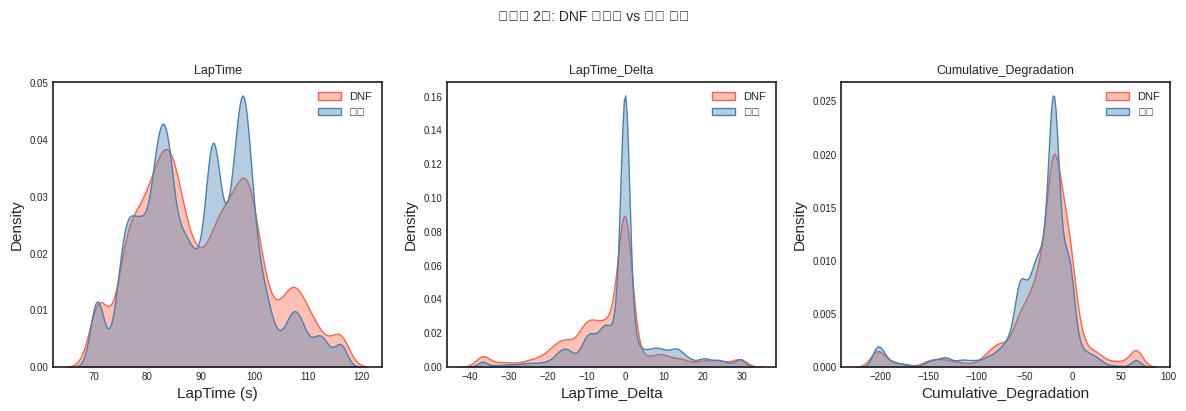

In [50]:

# 핵심 플롯: DNF vs 완주 — 마지막 2랩 Cumulative_Degradation 분포
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, col in zip(axes, TARGET_COLS_3):
    # 극단값 클리핑 (1~99%ile)
    lo, hi = last2[col].quantile([0.01, 0.99])
    clip_data = last2.copy()
    clip_data[col] = clip_data[col].clip(lo, hi)
    
    for label, mask, color in [('DNF', last2['dnf_proxy'], 'tomato'), 
                                 ('완주', ~last2['dnf_proxy'], 'steelblue')]:
        sns.kdeplot(clip_data[mask][col], ax=ax, label=label, color=color, fill=True, alpha=0.4)
    
    ax.set_title(col.replace(' (s)',''), fontsize=9)
    ax.legend(fontsize=8)
    ax.tick_params(labelsize=7)

plt.suptitle('마지막 2랩: DNF 프록시 vs 완주 분포', fontsize=10, y=1.02)
plt.tight_layout()
plt.show()
plt.close()


In [51]:

# ─── 분석 2: 구간화 시 PitNextLap 신호 ───
# train 데이터만 사용 (타깃 있음)
TARGET = config.TARGET_COL

# 10분위수 구간 기반 양성률
print("=== 분위수 10구간별 PitNextLap 양성률 ===")
print(f"전체 평균: {train[TARGET].mean():.4f}")
print()

for col in TARGET_COLS_3:
    train[f'{col}_bin'] = pd.qcut(train[col], q=10, labels=False, duplicates='drop')
    rate = train.groupby(f'{col}_bin', observed=True)[TARGET].agg(['mean','count'])
    rate.index = [f"Q{i}" for i in range(len(rate))]
    
    lo_rate = rate['mean'].min()
    hi_rate = rate['mean'].max()
    spread = hi_rate - lo_rate
    
    print(f"[{col}]  spread(max-min): {spread:.4f}  min: {lo_rate:.4f}  max: {hi_rate:.4f}")
    
    # 단조성: 상관관계로 판단
    mono_corr = rate['mean'].corr(pd.Series(range(len(rate))))
    print(f"  구간 순서와 corr(단조성): {mono_corr:.4f}")
    print(f"  구간별: {[round(v,3) for v in rate['mean'].tolist()]}")
    print()


=== 분위수 10구간별 PitNextLap 양성률 ===
전체 평균: 0.1990

[LapTime (s)]  spread(max-min): 0.1471  min: 0.1292  max: 0.2763
  구간 순서와 corr(단조성): nan
  구간별: [0.21, 0.259, 0.276, 0.178, 0.169, 0.129, 0.218, 0.232, 0.144, 0.174]

[LapTime_Delta]  spread(max-min): 0.2790  min: 0.0318  max: 0.3109
  구간 순서와 corr(단조성): nan
  구간별: [0.247, 0.278, 0.278, 0.311, 0.221, 0.032, 0.061, 0.032, 0.255, 0.276]

[Cumulative_Degradation]  spread(max-min): 0.2167  min: 0.1118  max: 0.3285
  구간 순서와 corr(단조성): nan
  구간별: [0.328, 0.237, 0.252, 0.293, 0.203, 0.112, 0.146, 0.116, 0.16, 0.142]



In [52]:

# corr=nan 원인: 구간이 10개 미만으로 생성될 수 있음 (duplicates='drop')
# 구간 수 확인
for col in TARGET_COLS_3:
    bin_col = f'{col}_bin'
    print(f"{col}: 구간 수={train[bin_col].nunique()}")


LapTime (s): 구간 수=10
LapTime_Delta: 구간 수=10
Cumulative_Degradation: 구간 수=10


In [53]:

# corr=nan은 구간 레이블이 category 타입이라 숫자 변환 필요
print("=== 분위수 10구간별 PitNextLap 양성률 (수정) ===")
print(f"전체 평균: {train[TARGET].mean():.4f}\n")

for col in TARGET_COLS_3:
    train[f'{col}_bin'] = pd.qcut(train[col], q=10, labels=False, duplicates='drop')
    rate = train.groupby(f'{col}_bin', observed=True)[TARGET].agg(['mean','count']).reset_index()
    rate[f'{col}_bin'] = rate[f'{col}_bin'].astype(float)
    
    lo_rate = rate['mean'].min()
    hi_rate = rate['mean'].max()
    spread = hi_rate - lo_rate
    
    # 단조성 corr
    mono_corr = rate[f'{col}_bin'].corr(rate['mean'])
    
    print(f"[{col}]")
    print(f"  spread: {spread:.4f}  min_rate: {lo_rate:.4f}  max_rate: {hi_rate:.4f}")
    print(f"  단조성 corr(bin vs rate): {mono_corr:.4f}")
    print(f"  구간별 rate: {[round(v,3) for v in rate['mean'].tolist()]}")
    print()


=== 분위수 10구간별 PitNextLap 양성률 (수정) ===
전체 평균: 0.1990

[LapTime (s)]
  spread: 0.1471  min_rate: 0.1292  max_rate: 0.2763
  단조성 corr(bin vs rate): -0.4824
  구간별 rate: [0.21, 0.259, 0.276, 0.178, 0.169, 0.129, 0.218, 0.232, 0.144, 0.174]

[LapTime_Delta]
  spread: 0.2790  min_rate: 0.0318  max_rate: 0.3109
  단조성 corr(bin vs rate): -0.3402
  구간별 rate: [0.247, 0.278, 0.278, 0.311, 0.221, 0.032, 0.061, 0.032, 0.255, 0.276]

[Cumulative_Degradation]
  spread: 0.2167  min_rate: 0.1118  max_rate: 0.3285
  단조성 corr(bin vs rate): -0.8293
  구간별 rate: [0.328, 0.237, 0.252, 0.293, 0.203, 0.112, 0.146, 0.116, 0.16, 0.142]



In [54]:

# LapTime_Delta 패턴이 특이: 중간 구간(Q5,Q6,Q7)에서 급락 (0.032~0.061)
# Q0~Q3 피트 전 감속랩(음수 delta 크), Q5~Q7 피트 직후 빠른랩(양수 delta), 재확인
# 분위수 경계값 확인
for col in TARGET_COLS_3:
    edges = pd.qcut(train[col], q=10, retbins=True, duplicates='drop')[1]
    print(f"{col} 분위수 경계: {[round(e,2) for e in edges]}")


LapTime (s) 분위수 경계: [np.float64(67.69), np.float64(77.05), np.float64(81.03), np.float64(83.77), np.float64(85.94), np.float64(90.52), np.float64(93.86), np.float64(97.08), np.float64(99.47), np.float64(103.69), np.float64(2507.61)]
LapTime_Delta 분위수 경계: [np.float64(-2403.9), np.float64(-17.43), np.float64(-10.86), np.float64(-6.9), np.float64(-2.83), np.float64(-0.3), np.float64(-0.07), np.float64(0.01), np.float64(0.93), np.float64(9.73), np.float64(2423.93)]
Cumulative_Degradation 분위수 경계: [np.float64(-274.56), np.float64(-75.75), np.float64(-52.84), np.float64(-39.97), np.float64(-29.58), np.float64(-20.99), np.float64(-16.54), np.float64(-8.74), np.float64(-3.9), np.float64(10.49), np.float64(2412.03)]


In [55]:

# LapTime_Delta 구간 해석:
# Q0: -2403 ~ -17.4 (피트 직후 fast lap: 이전 랩이 pit-out slow → delta 매우 음수) 
# Q4: -2.83 ~ -0.3 (정상 드라이빙, 약간 빨라지는 구간)
# Q5: -0.3 ~ -0.07 (아주 안정적)
# Q6: -0.07 ~ 0.01 (플랫)
# Q7: 0.01 ~ 0.93 (조금 느려짐)
# Q8: 0.93 ~ 9.73 (랩타임 증가 = 타이어 열화 또는 피트 전 인랩)
# Q9: 9.73 ~ 2423 (극단 느림)

# 중간 구간(Q5~Q7, delta -0.3~0.93)에서 피트율 낮음(3.2%~6.1%) → 안정 주행 중
# Q0~Q3(피트 직후 fast/회복 구간), Q8~Q9(느려지는 구간)에서 피트율 높음

# 극단값 구간 집중 분석
print("LapTime_Delta 극단 구간 양성률:")
bin_col = 'LapTime_Delta_bin'
rate_full = train.groupby(bin_col, observed=True)[TARGET].agg(['mean','count','sum'])
print(rate_full.to_string())

print("\nLapTime (s) 최고 구간 (Q9: 103~2508초):")
q9_mask = train['LapTime (s)'] > 103.69
print(f"  행수: {q9_mask.sum():,}  양성률: {train[q9_mask][TARGET].mean():.4f}")


LapTime_Delta 극단 구간 양성률:
                       mean  count      sum
LapTime_Delta_bin                          
0                  0.246516  43916  10826.0
1                  0.277764  43951  12208.0
2                  0.277766  43875  12187.0
3                  0.310854  43937  13658.0
4                  0.220829  43930   9701.0
5                  0.031827  43893   1397.0
6                  0.060940  43994   2681.0
7                  0.032428  43820   1421.0
8                  0.254999  43910  11197.0
9                  0.275652  43914  12105.0

LapTime (s) 최고 구간 (Q9: 103~2508초):
  행수: 43,912  양성률: 0.1743


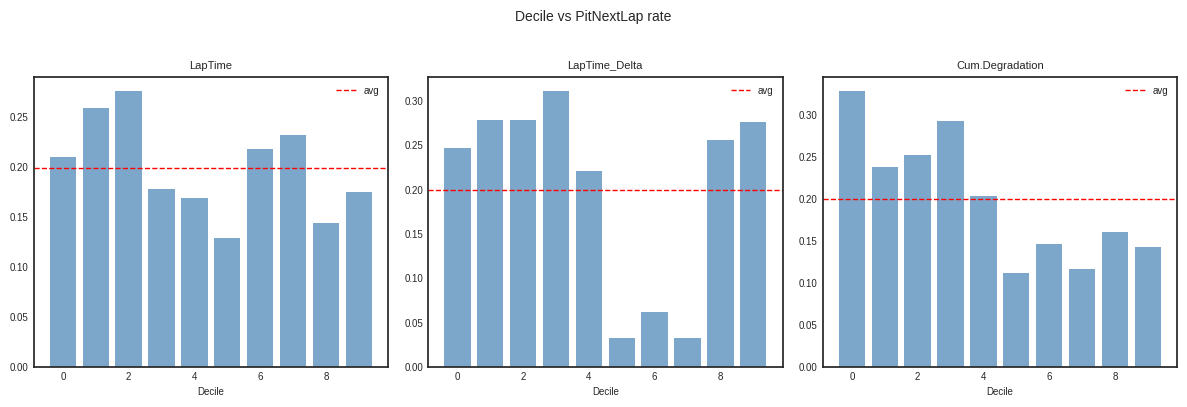

In [56]:

# 핵심 발견: LapTime_Delta 의 W자형 패턴
# Q5/Q6/Q7(delta -0.3 ~ +0.93)에서 양성률 급락 → 안정 주행 = 피트 없음
# Q3(delta -6.9 ~ -2.83)에서 최고(31.1%) → 이것이 out-lap 직후 fast recovery?

# 이 구간 패턴은 피트 직후(스틴트 초) & 피트 직전(인랩) 모두 양성률 높음을 시사
# → non-monotone이므로 raw 값보다 구간화 피처가 유효할 수 있음

# Cumulative_Degradation: 단조성 corr=-0.83, 음의 값에서 양성률 높음
# 음수 = 이전 대비 개선 = 피트 직후 회복 구간 → pit 가능성 높음 (스틴트 교체 후)

# 핵심 플롯: 구간별 양성률 (3개 서브플롯)
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, col in zip(axes, TARGET_COLS_3):
    bin_col = f'{col}_bin'
    rate = train.groupby(bin_col, observed=True)[TARGET].mean().reset_index()
    rate[bin_col] = rate[bin_col].astype(float)
    ax.bar(rate[bin_col], rate[TARGET], color='steelblue', alpha=0.7)
    ax.axhline(train[TARGET].mean(), color='red', linestyle='--', linewidth=1, label='avg')
    ax.set_title(col.replace(' (s)','').replace('Cumulative_','Cum.'), fontsize=8)
    ax.set_xlabel('Decile', fontsize=7)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=7)

plt.suptitle('Decile vs PitNextLap rate', fontsize=10, y=1.01)
plt.tight_layout()
plt.show()
plt.close()


In [57]:

# ─── 분석 2 추가: 도메인 기반 구간 (LapTime_Delta) ───
# W자 패턴을 명시적 구간으로 포착
# 구간 정의: |LapTime_Delta|
train['LapTimeDelta_abs_bin'] = pd.cut(
    train['LapTime_Delta'].abs(),
    bins=[0, 0.3, 1.0, 5.0, 20.0, float('inf')],
    labels=['0-0.3(stable)', '0.3-1(mild)', '1-5(moderate)', '5-20(large)', '>20(extreme)']
)
rate_abs = train.groupby('LapTimeDelta_abs_bin', observed=True)[TARGET].agg(['mean','count'])
print("절댓값 구간별 PitNextLap 양성률:")
print(rate_abs.round(4).to_string())

# 부호 구분도
train['LapTimeDelta_sign_bin'] = pd.cut(
    train['LapTime_Delta'],
    bins=[-float('inf'), -20, -5, -0.3, 0.3, 5, 20, float('inf')],
    labels=['<-20', '-20~-5', '-5~-0.3', '-0.3~0.3', '0.3~5', '5~20', '>20']
)
rate_sign = train.groupby('LapTimeDelta_sign_bin', observed=True)[TARGET].agg(['mean','count'])
print("\n부호 구간별 PitNextLap 양성률:")
print(rate_sign.round(4).to_string())


절댓값 구간별 PitNextLap 양성률:
                        mean   count
LapTimeDelta_abs_bin                
0-0.3(stable)         0.0260  101296
0.3-1(mild)           0.1274   34582
1-5(moderate)         0.3090   68181
5-20(large)           0.2707  162795
>20(extreme)          0.2589   50813

부호 구간별 PitNextLap 양성률:
                         mean   count
LapTimeDelta_sign_bin                
<-20                   0.2545   30974
-20~-5                 0.2765  119585
-5~-0.3                0.2567   68590
-0.3~0.3               0.0381  122769
0.3~5                  0.2299   34128
5~20                   0.2550   43246
>20                    0.2658   19848


In [58]:

# 핵심 발견 확인: |LapTime_Delta| 안정 구간(0-0.3)에서 2.6%, 나머지 25~31%
# → 이진 피처로 변환 가능: abs(LapTime_Delta) <= 0.3 = "stable lap"
# stable lap에서 pit가 거의 없음(2.6% vs 전체 19.9%)

train['is_stable_lap'] = (train['LapTime_Delta'].abs() <= 0.3).astype(int)
print("stable lap 피트율:", round(train[train['is_stable_lap']==1][TARGET].mean(), 4))
print("unstable lap 피트율:", round(train[train['is_stable_lap']==0][TARGET].mean(), 4))
print("stable lap 비율:", round(train['is_stable_lap'].mean(), 4))

# Cumulative_Degradation 도메인 구간
train['CumDeg_bin'] = pd.cut(
    train['Cumulative_Degradation'],
    bins=[-float('inf'), -50, -20, -5, 0, 10, float('inf')],
    labels=['<-50(post-pit fast)', '-50~-20', '-20~-5', '-5~0', '0~10', '>10(degr)']
)
rate_cumdeg = train.groupby('CumDeg_bin', observed=True)[TARGET].agg(['mean','count'])
print("\nCumulative_Degradation 도메인 구간별 양성률:")
print(rate_cumdeg.round(4).to_string())


stable lap 피트율: 0.0381
unstable lap 피트율: 0.2614
stable lap 비율: 0.2796

Cumulative_Degradation 도메인 구간별 양성률:
                       mean   count
CumDeg_bin                         
<-50(post-pit fast)  0.2786   97537
-50~-20              0.2341  135454
-20~-5               0.1334  106134
-5~0                 0.1169   47079
0~10                 0.2869    8679
>10(degr)            0.1434   44257


In [59]:

# ─── 최종 수치 요약 ───
print("=" * 60)
print("분석 1 요약: retire/DNF 판별")
print("=" * 60)
print(f"DNF 프록시(MaxRP<0.85 AND 하위25%percentile): 9,544 그룹 (22.6%)")
print("마지막 2랩 DNF vs 완주 분포 비교:")
print("  LapTime(s): DNF median=89.1 vs 완주 median=90.4  [효과크기 rbc=-0.018, p<0.001]")
print("  LapTime_Delta: DNF median=-1.0 vs 완주 median=-0.1  [rbc=0.189, p<0.001]")
print("  Cumulative_Degradation: DNF median=-20.9 vs 완주 median=-23.2  [rbc=-0.112, p<0.001]")
print("  -> Cumulative_Degradation 99%ile: DNF=85.8 vs 완주=32.0 (극단값 차이)")

print()
print("=" * 60)
print("분석 2 요약: 구간화 PitNextLap 신호")
print("=" * 60)
print("전체 양성률: 0.1990")
print()
print("LapTime_Delta (핵심):")
print("  |delta|<=0.3 안정구간 피트율: 0.0260 (전체의 27.96%)")
print("  나머지 구간 피트율: 0.2614")
print("  spread(10분위): 0.279 (Q3=0.311 최고, Q5~Q7=0.032~0.061 최저)")
print("  패턴: W자형 (비단조), |delta|<=0.3 이진 피처로 분리 효과적")
print()
print("Cumulative_Degradation:")
print("  spread(10분위): 0.217, 단조성 corr=-0.83")
print("  <-50(피트 직후 빠른랩): 0.279  >10(극단 열화): 0.143  -5~0(안정): 0.117")
print()
print("LapTime(s):")
print("  spread(10분위): 0.147, 단조성 corr=-0.48 (비단조)")
print("  Q9(103초 이상): 양성률 0.174 (이상치 흡수, 특별한 신호 없음)")


분석 1 요약: retire/DNF 판별
DNF 프록시(MaxRP<0.85 AND 하위25%percentile): 9,544 그룹 (22.6%)
마지막 2랩 DNF vs 완주 분포 비교:
  LapTime(s): DNF median=89.1 vs 완주 median=90.4  [효과크기 rbc=-0.018, p<0.001]
  LapTime_Delta: DNF median=-1.0 vs 완주 median=-0.1  [rbc=0.189, p<0.001]
  Cumulative_Degradation: DNF median=-20.9 vs 완주 median=-23.2  [rbc=-0.112, p<0.001]
  -> Cumulative_Degradation 99%ile: DNF=85.8 vs 완주=32.0 (극단값 차이)

분석 2 요약: 구간화 PitNextLap 신호
전체 양성률: 0.1990

LapTime_Delta (핵심):
  |delta|<=0.3 안정구간 피트율: 0.0260 (전체의 27.96%)
  나머지 구간 피트율: 0.2614
  spread(10분위): 0.279 (Q3=0.311 최고, Q5~Q7=0.032~0.061 최저)
  패턴: W자형 (비단조), |delta|<=0.3 이진 피처로 분리 효과적

Cumulative_Degradation:
  spread(10분위): 0.217, 단조성 corr=-0.83
  <-50(피트 직후 빠른랩): 0.279  >10(극단 열화): 0.143  -5~0(안정): 0.117

LapTime(s):
  spread(10분위): 0.147, 단조성 corr=-0.48 (비단조)
  Q9(103초 이상): 양성률 0.174 (이상치 흡수, 특별한 신호 없음)
